Created by Sanish Bhochhibhoya (03/08/2025)

#### Steps:
1) Boundary Creation
2) Utils Creation
3) Creating a domain2D for each
4) merging domain3d

#### Remaining (to clean):
1) Soil and Util types random generation
2) GWT
3) Mean and Std. of properties
4) Spatial

#### To do:
1) Utils2D
2) SpatialCorrelationMethod2
3) Saving the docs
4) adjustment to different platform like SPECFEM3D, GPRMax

In [9]:
import sys, importlib
sys.path.insert(0, r'F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator')

In [10]:
import geomodgen2d.interfaces_creator2d as interface_creator
import geomodgen2d.discretized_interfaces2d as discretized_interfaces2d
from geomodgen2d.discretized_domain2d import DiscretizedDomain2D
import geomodgen2d.general_functions as f
import numpy as np

In [11]:
model_sett={
    'x_limit':5,
    'z_limit':4,
    'del_x_boundary':0.2,    #del_y value for boundary generation and spatial 
    'del_x_spatial':0.5,    #del_y value for boundary generation and spatial 
    'del_z_spatial':0.5,
    'del_x_final': 0.1,  #refining del_z for utilities generation
    'del_z_final': 0.1,
    'refine_interp_method':'linear',
    'random_seed':4,
    'spatial_theta_x':100,
    'spatial_theta_z':0.5,
}


boundary_sett= {'flag_filter':True, 'flag_processing':True,
    'generator_settings_dict':{
                 'generator_option':'uniform',    # options: 'uniform', 'normal', 'fbm'
                 'max_dz_per_unit_length':1,   # Required for 'uniform' only
                 'H':0.75,  # Required for 'fbm' only
                 'method':'daviesharte',   # Required for 'fbm' only
                 'length':15,   # Required for 'fbm' only
                 'std':2     # Required for 'normal' only Mean has to be zero
                },
    'random_init_boundary_option':'random', #options: 'random', 'equidistant', nparray
    'filter_settings_dict': {
                 'filter_window_length':20, 
                 'filter_polyorder':3,
                        },
    'boundary_overlap_bottom_priority':True,
    }

n_interfaces = 3

r_seed = model_sett['random_seed']
rnd_no = np.random.default_rng(seed=r_seed)

In [89]:
importlib.reload(interface_creator)
span_x, span_z, del_x_boundary, del_z_spatial = model_sett['x_limit'], model_sett['z_limit'],  model_sett['del_x_boundary'],  model_sett['del_z_spatial']
r_seed, theta_x, theta_z = model_sett['random_seed'], model_sett['spatial_theta_x'], model_sett['spatial_theta_z']
del_x_spatial = model_sett['del_x_spatial']
del_x_final, del_z_final, interp_method = model_sett['del_x_final'], model_sett['del_z_final'], model_sett['refine_interp_method']

domain_spatial = DiscretizedDomain2D(span_x, span_z, del_x_boundary, del_z_spatial)
domain_final = DiscretizedDomain2D(span_x, span_z, del_x_final, del_z_final)

<Axes: xlabel='Distance', ylabel='Depth'>

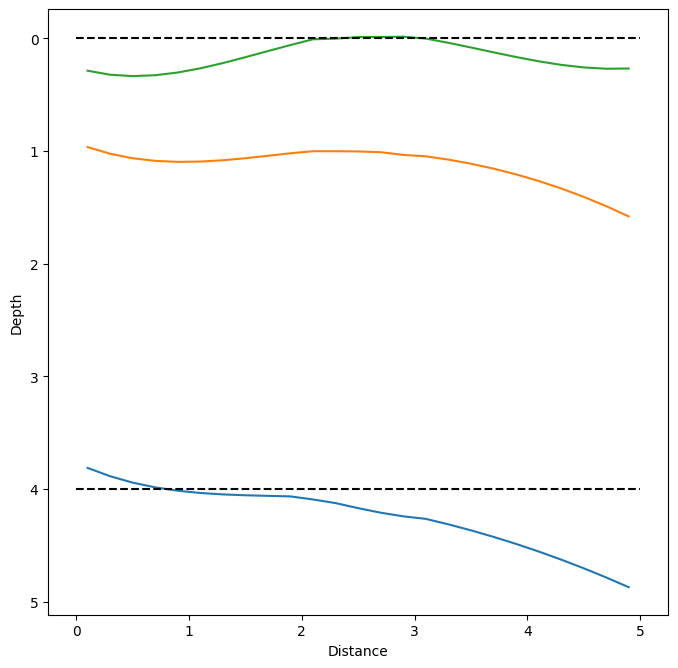

In [90]:

boundary = interface_creator.DefaultInterfaceCreator(
    domain_spatial, n_interfaces, rnd_no, boundary_sett)
boundary.interfaces.plot_boundary()

<Axes: xlabel='Distance', ylabel='Depth'>

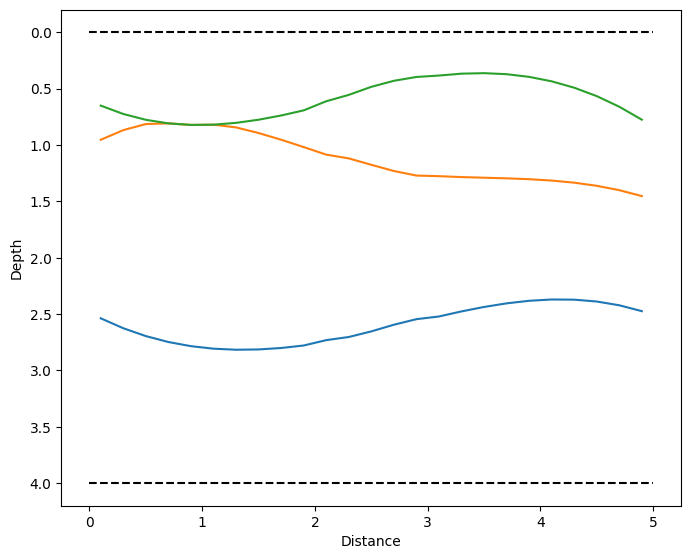

In [91]:

boundary = interface_creator.DefaultInterfaceCreator(
    domain_spatial, n_interfaces, rnd_no, boundary_sett)
boundary.interfaces.plot_boundary()

<Axes: xlabel='Distance', ylabel='Depth'>

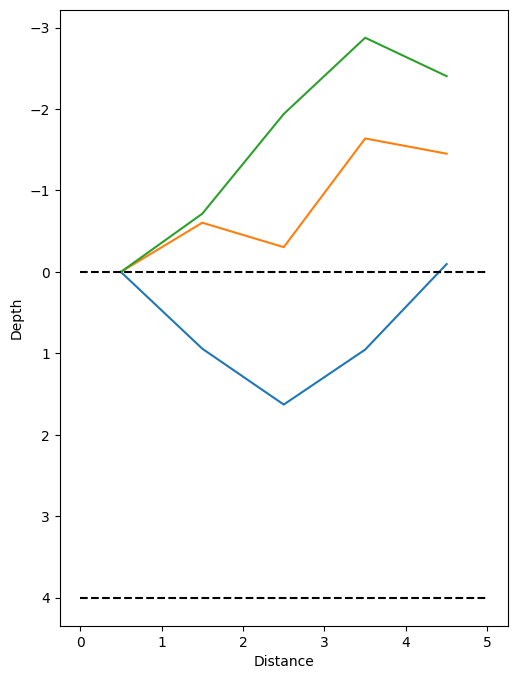

In [16]:
importlib.reload(interface_creator)
domain2D1 = DiscretizedDomain2D(
    span_x=5, span_z=4, dx=1, dz=1
)

boundary2D1 = interface_creator.AbstractInterfacesCreator2D(
            domain=domain2D1, n_interfaces=3, rng=np.random.default_rng(2))

random_generator_settings_dict = {
                 'generator_option':'uniform',    # options: 'uniform', 'normal', 'fbm'
                 'max_dz_per_unit_length':1.5,}
boundary2D1.generate_rough_interfaces(random_generator_settings_dict)
boundary2D1.io.plot_boundary()


[[ 0.7 -0.2]
 [ 0.5  2. ]
 [ 2.   3. ]
 [ 1.  -2. ]
 [-0.2  0.5]]
3
[[False False]
 [False False]
 [False False]
 [False False]
 [False False]]
N_x_coord = 5, N_interfaces = 3
Interface Matrix (Transposed) 
 [[1.  0.5 0.  2.  2. ]
 [1.5 1.  2.  2.  2. ]
 [1.5 3.  5.  2.  2.5]]


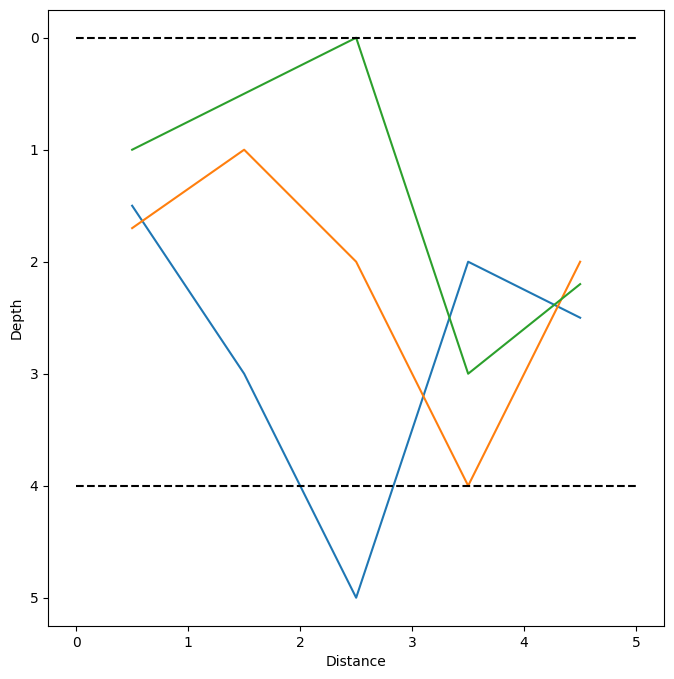

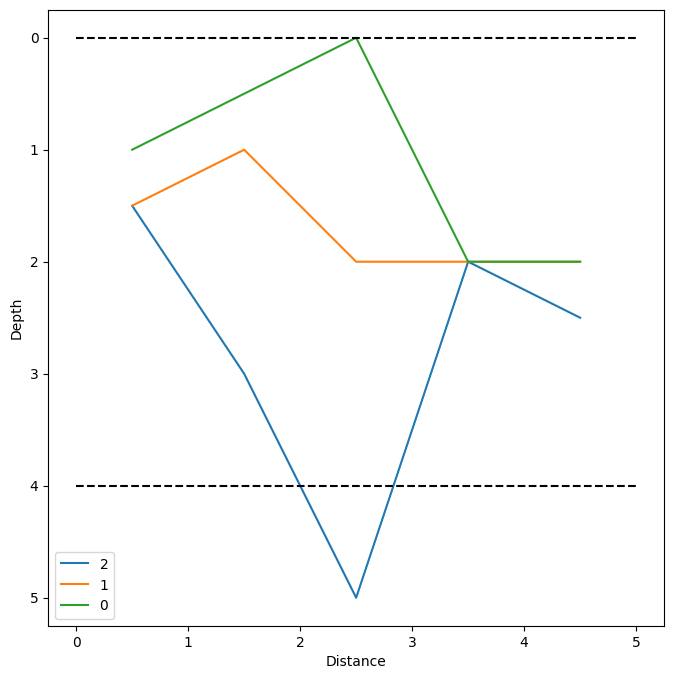

In [17]:
boundary2D1.set_interfaces_matrix(np.array([[1,0.5,0,3,2.2],
                                                               [1.7,1,2,4,2],
                                                               [1.5,3,5,2,2.5]]).T)

print(np.diff(boundary2D1.io.interfaces_matrix))
print(np.sum(np.diff(boundary2D1.io.interfaces_matrix)<0))
bottom_erosion = False
ax = boundary2D1.io.plot_boundary()

boundary2D1.processing_interface(bottom_erosion, False)
    
ax = boundary2D1.io.plot_boundary()
ax.legend()
print(np.diff(boundary2D1.io.interfaces_matrix)<0)
boundary2D1.io.print()

In [18]:
np.diff([1,3,2])

array([ 2, -1])

In [19]:
# print(boundary.boundary_array)
method = 'random_sum'
# method = 'random_sort'
method = 'equidistant'
print(boundary.boundary_array)

# boundary.gen_using_def_process(boundary_sett, rnd_no=rnd_no)
boundary_settings_dict = boundary_sett
boundary.generating_boundary(boundary_settings_dict['generator_settings_dict'], rnd_no = rnd_no)
print(boundary.boundary_array)

boundary.filtering_boundary(**boundary_settings_dict['filter_settings_dict'])
boundary.boundary_init_points(init_boundary=boundary_settings_dict['random_init_boundary_option'] , rnd_no = rnd_no) #None means get one from 
boundary.processing_boundary(boundary_settings_dict['boundary_overlap_bottom_priority'])
print(boundary.boundary_array)


AttributeError: 'DefaultInterfaceCreator' object has no attribute 'boundary_array'

In [105]:
importlib.reload(boundary_defn)
importlib.reload(f)
boundary.remeshing_boundary(model_sett['del_x_final'])
boundary.plot_boundary()


NameError: name 'boundary_defn' is not defined

In [92]:
import geomodgen2d.lithological_domain2d as lithological_domain2d
importlib.reload(lithological_domain2d)
name = 'asdf'
lit = lithological_domain2d.LithologicalDomain2D(span_x, span_z, del_x_final, del_z_final, name)
lit.get_matrix_from_boundary(boundary)
# lit.remeshing_layered_matrix(span_x, span_z, del_x_final, del_z_final)
lit.plot2d()

lit.layered_matrix.shape

TypeError: LithologicalDomain2D.__init__() takes from 2 to 4 positional arguments but 6 were given

array([[0.65085754, 0.95377936, 2.53747676],
       [0.72474515, 0.86805646, 2.62551802],
       [0.77651243, 0.81427701, 2.69515637],
       [0.80822408, 0.80822408, 2.74771838],
       [0.82194483, 0.82194483, 2.78453061],
       [0.81973938, 0.81973938, 2.8069196 ],
       [0.80367244, 0.84385402, 2.81621191],
       [0.77580873, 0.89373707, 2.81373409],
       [0.73821296, 0.95314167, 2.8008127 ],
       [0.69294984, 1.01833085, 2.77877429],
       [0.61208867, 1.08539597, 2.73117131],
       [0.55553276, 1.11883124, 2.70333864],
       [0.48404561, 1.17556346, 2.65363399],
       [0.43065308, 1.23053085, 2.59451238],
       [0.39660731, 1.27105067, 2.54522177],
       [0.38399363, 1.27664265, 2.52128441],
       [0.36725294, 1.28462846, 2.47634472],
       [0.36281273, 1.29023703, 2.43689997],
       [0.37185492, 1.29573269, 2.40484804],
       [0.39556139, 1.30337981, 2.38208681],
       [0.43511406, 1.31544271, 2.37051416],
       [0.49169484, 1.33418576, 2.37202795],
       [0.

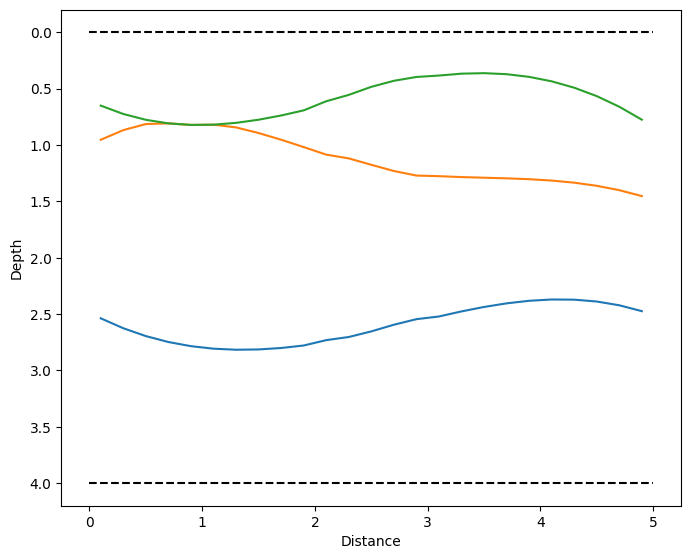

In [106]:
boundary.io.plot_boundary()
boundary.io.interfaces_matrix

N_x_coord = 25, N_interfaces = 3
Interface Matrix (Transposed) 
 [[0.65085754 0.72474515 0.77651243 0.80822408 0.82194483 0.81973938
  0.80367244 0.77580873 0.73821296 0.69294984 0.61208867 0.55553276
  0.48404561 0.43065308 0.39660731 0.38399363 0.36725294 0.36281273
  0.37185492 0.39556139 0.43511406 0.49169484 0.56648561 0.6606683
  0.7754248 ]
 [0.95377936 0.86805646 0.81427701 0.80822408 0.82194483 0.81973938
  0.84385402 0.89373707 0.95314167 1.01833085 1.08539597 1.11883124
  1.17556346 1.23053085 1.27105067 1.27664265 1.28462846 1.29023703
  1.29573269 1.30337981 1.31544271 1.33418576 1.36187329 1.40076965
  1.45313918]
 [2.53747676 2.62551802 2.69515637 2.74771838 2.78453061 2.8069196
  2.81621191 2.81373409 2.8008127  2.77877429 2.73117131 2.70333864
  2.65363399 2.59451238 2.54522177 2.52128441 2.47634472 2.43689997
  2.40484804 2.38208681 2.37051416 2.37202795 2.38852608 2.42190641
  2.47406682]]


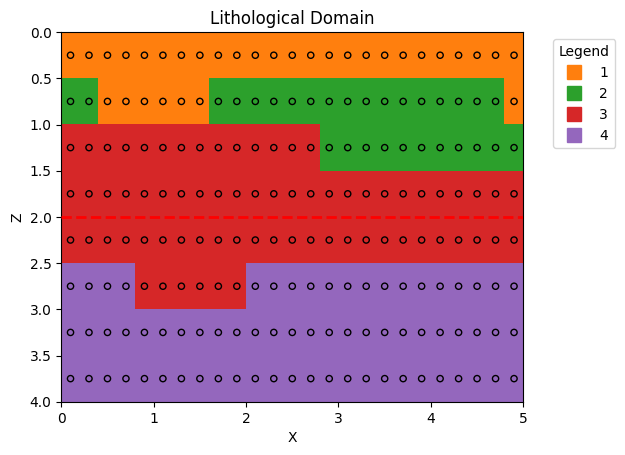

In [107]:
import geomodgen2d.lithological_domain2d as lithological_domain2d
importlib.reload(lithological_domain2d)
name = 'asdf'
lit = lithological_domain2d.LithologicalDomain2D(boundary.io, 2, name)
# lit.remeshing_layered_matrix(span_x, span_z, del_x_final, del_z_final)
lit.plot2d(discrete_point_size = 20)
# boundary.io.print()
lit.discretizedInterfaces3D_instance.print()

In [122]:
a = lithological_domain2d.GlobalSurfaceInterfaceConfig
a.set_surface_interface(None, force_set = True)
b = lithological_domain2d.GlobalSurfaceInterfaceConfig.set_surface_interface(boundary.io)
a.set_surface_interface(None, force_set = True)


In [123]:
a.get_surface_interface()

(None, 'pile', False, 482453427013266304)

Provided reference x_val (0) is not available in boundary x_ranges: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95 1.05 1.15 1.25 1.35
 1.45 1.55 1.65 1.75 1.85 1.95 2.05 2.15 2.25 2.35 2.45 2.55 2.65 2.75
 2.85 2.95 3.05 3.15 3.25 3.35 3.45 3.55 3.65 3.75 3.85 3.95 4.05 4.15
 4.25 4.35 4.45 4.55 4.65 4.75 4.85 4.95]. So using nearest value (i.e., 0.05)
[0.21635447]


<Axes: xlabel='X', ylabel='Z'>

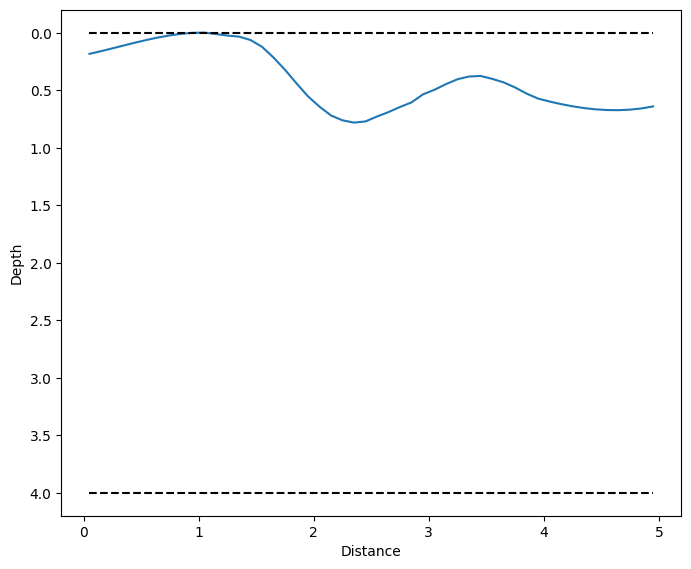

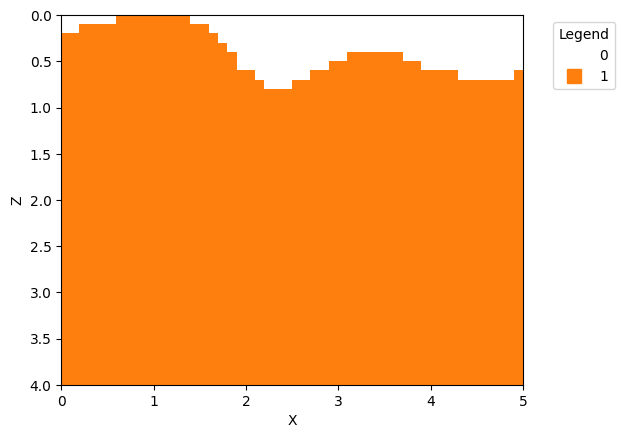

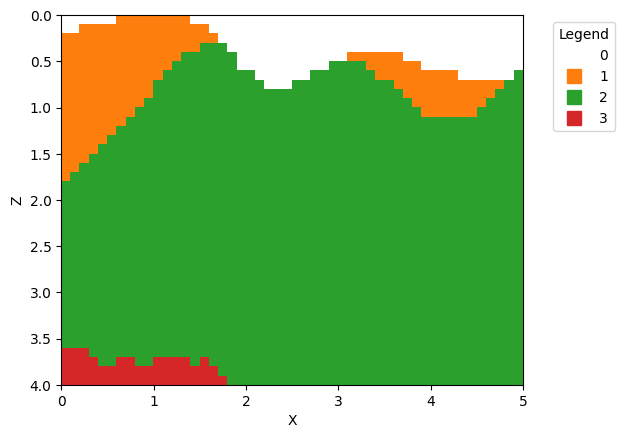

In [7]:
importlib.reload(boundary_defn)
surf = boundary_defn.SurfaceBoundaryCreator(span_x, span_z, del_x_final, del_z_spatial,gen_param=3, rnd_no=rnd_no)
surf.plot_boundary()
lit.add_surface_boundary_to_curr_boundary(surf, method='pile')
lit.plot2d()

In [8]:
surf.boundary_array[0,int(9.0)]

0.0020072108045836035

In [9]:
3.999//2

1.0

[0.6270473632262658, 1]
[2.4037350096303225, 2]
[2.6812246278490575, 2.3]
(40, 50)


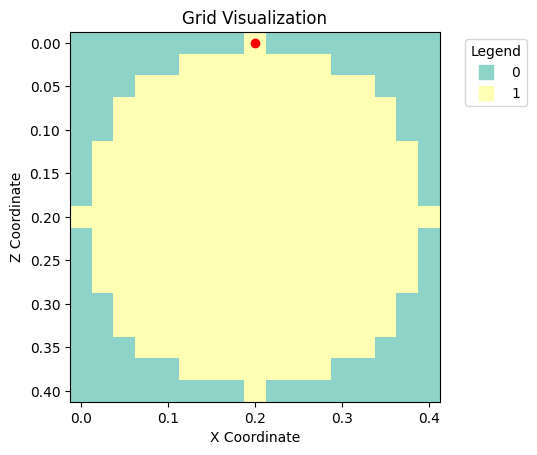

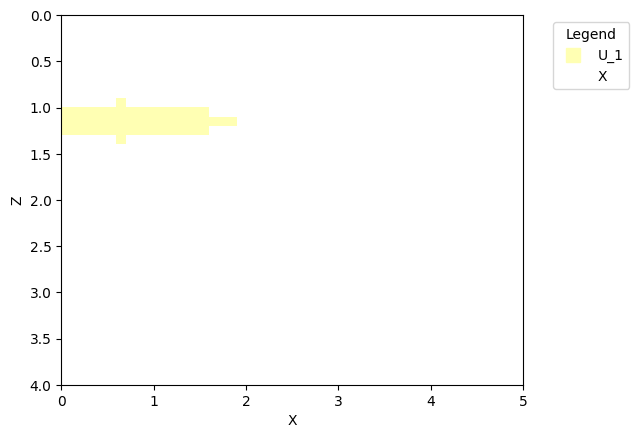

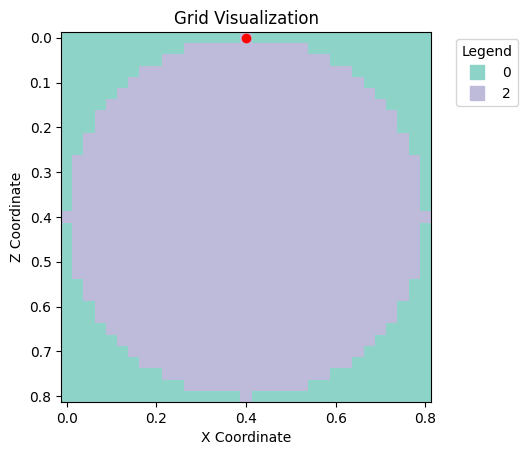

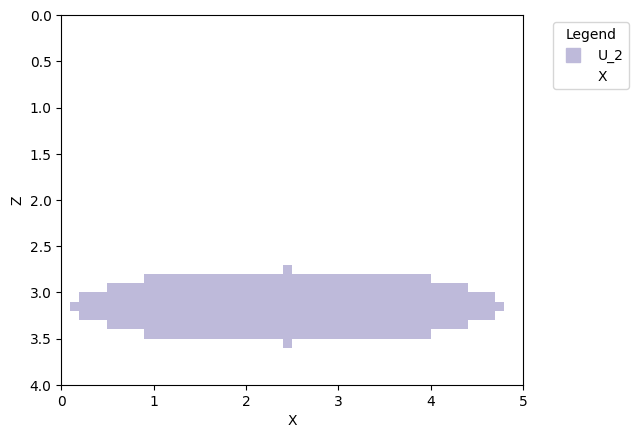

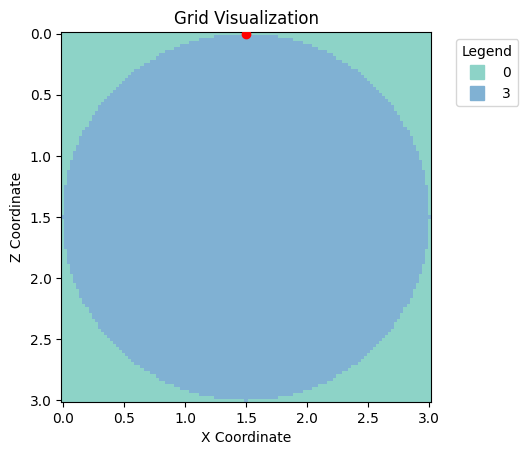

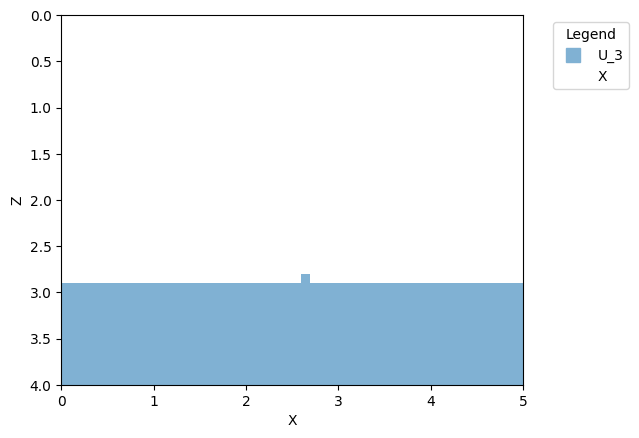

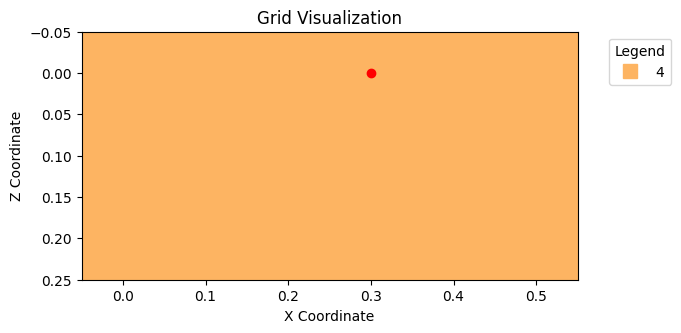

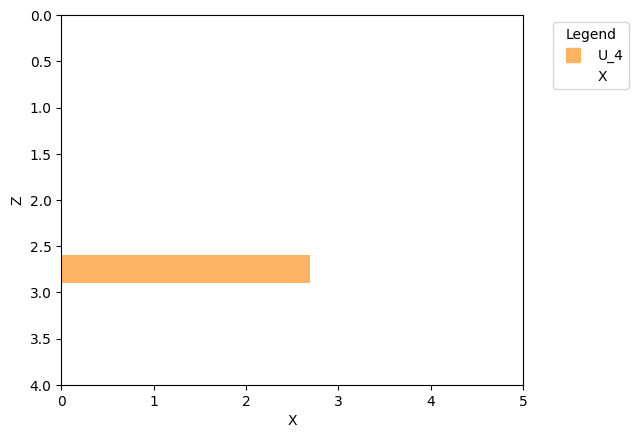

In [10]:
import geomodgen2d.utils_2d as utils_2d
import geomodgen2d.utils_3d_functions as utils_3d_f
importlib.reload(utils_2d)
importlib.reload(f)
importlib.reload(utils_3d_f)
importlib.reload(lithological_domain2d)

r_circ = [.2, .4, 1.5]
d_circ = [1,2,2.3]
util_lit_list = []
i=0
for r, d in zip(r_circ, d_circ):
    x_rnd = rnd_no.uniform(0,lit.span_x,1)[0] # Random x_coord
    circ_shape_class = utils_2d.Utils2D(del_x = model_sett['del_x_final'], del_z = model_sett['del_z_final'], refining_factor=4)
    circ_shape_class.circular_2d(r, ref='top', util_id = i+1)
    circ_shape_class.plot()
    util_lit = lithological_domain2d.LithologicalDomain2D_from_Utils2D(span_x, span_z, del_x_final, del_z_final, 'util', surfaceBoundaryCreator_class=surf)
    util_lit.get_matrix_from_utils2d(circ_shape_class, [d, x_rnd], [0,0,80], added_prefix='U')
    util_lit.plot2d()
    i+=1
    print([x_rnd,d])
    util_lit_list.append(util_lit)

rect_shape_layer = utils_2d.Utils2D(del_x = model_sett['del_x_final'], del_z = model_sett['del_z_final'])
rect_shape_layer.rectangle_2d(lx=.5, lz=.2, util_id=i+1, ref='top')
rect_shape_layer.plot()

d = 1.3
util_lit = lithological_domain2d.LithologicalDomain2D_from_Utils2D(span_x, span_z, del_x_final, del_z_final, 'util', surfaceBoundaryCreator_class=surf)
util_lit.get_matrix_from_utils2d(rect_shape_layer, [x_rnd,d], [0,0,80], added_prefix='U')
util_lit.plot2d()
util_lit_list.append(util_lit)
print(util_lit_list[i].layered_matrix.shape)


In [14]:
util_lit_list

Circular 2d of radius 0.2, then rotated by angle (in degrees) of 80 about z-axis + Circular 2d of radius 0.4, then rotated by angle (in degrees) of 80 about z-axis + Circular 2d of radius 1.5, then rotated by angle (in degrees) of 80 about z-axis + Rectangular 2d of size (lz x lx) = (0.2 x 0.5), then rotated by angle (in degrees) of 80 about z-axis


True

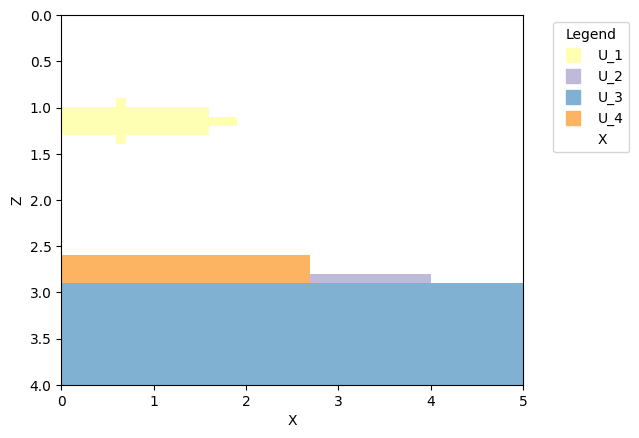

In [15]:
if len(util_lit_list)!=0:
    merged_util_lit = lithological_domain2d.LithologicalDomain2D_from_Utils2D(span_x, span_z, del_x_final, del_z_final, 'util_merged', surfaceBoundaryCreator_class=surf)
    for util_lit in util_lit_list:
        merged_util_lit.merge_with_another_lithological_domain(util_lit)
    # lit.merge_with_another_lithological_domain(merged_util_lit)
merged_util_lit.plot2d()
print(merged_util_lit.utils_description)
merged_util_lit.overlap

<Axes: xlabel='X', ylabel='Z'>

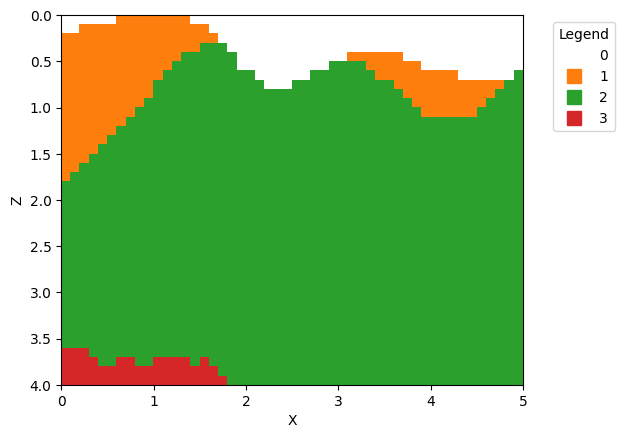

In [16]:
lit.plot2d()

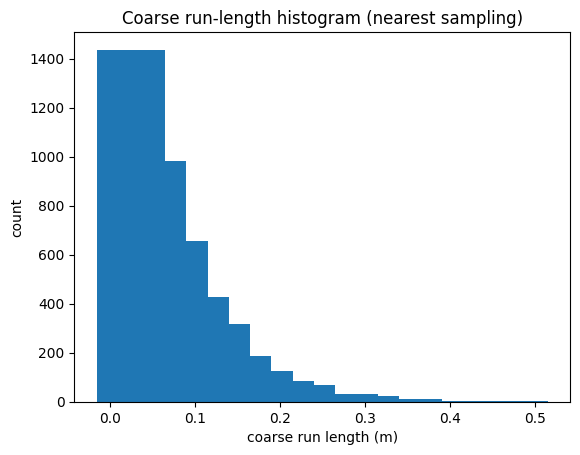

1 coarse cells → 0.03 m : count 1436
2 coarse cells → 0.05 m : count 984
3 coarse cells → 0.08 m : count 654
4 coarse cells → 0.10 m : count 427
5 coarse cells → 0.12 m : count 318
6 coarse cells → 0.15 m : count 187
7 coarse cells → 0.18 m : count 124
8 coarse cells → 0.20 m : count 83


In [4]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

np.random.seed(0)

# params
fine_dx = 0.025
coarse_dx = 0.025
block = int(coarse_dx / fine_dx)  # =4

# build a long single utility: for each along-track column choose a thickness L ~ U(1,6)
Ncols = 20000               # along-track length (fine cells)
height = 40                 # vertical size in fine cells (big enough)
# create empty grid
grid = np.zeros((height, Ncols), dtype=np.int8)

# vertical anchor: put utility somewhere in middle vertically
base = 10  # top index of utility (so utility occupies rows base .. base+L-1)
for j in range(Ncols):
    L = np.random.randint(1,7)           # thickness in fine cells (1..6)
    grid[base:base+L, j] = 1             # single utility labeled '1'

# simulate RegularGridInterpolator(nearest) sampling: sample one fine cell per block
# choose offset 0..block-1 that RGI would pick (depends on alignment). Try offset=1 as example
offset = 10
sampled_cols = np.arange(offset, Ncols, block)  # indices of sampled fine columns
# for each sampled column we need only whether sampled point is inside utility:
# pick the sampled fine-row index that corresponds to the coarse center vertically.
# For simplicity we sample the same vertical row that corresponds to utility mid-height:
sample_row = base + 2  # pick a representative vertical sample row (nearest)
sampled = grid[sample_row, sampled_cols]  # 1 if utility present at that sampled point

# compute run-lengths (consecutive 1s) in sampled sequence
runs = []
cur = sampled[0]; cnt = 1
for v in sampled[1:]:
    if v == cur:
        cnt += 1
    else:
        if cur == 1:
            runs.append(cnt)
        cur = v; cnt = 1
# final
if cur == 1:
    runs.append(cnt)
runs = np.array(runs)

# histogram of coarse-run lengths in meters
counts = Counter(runs)
xs = np.array(sorted(counts.keys())) * coarse_dx
ys = np.array([counts[k] for k in sorted(counts.keys())])

plt.bar(xs, ys, width=0.08)
plt.xlabel('coarse run length (m)')
plt.ylabel('count')
plt.title('Coarse run-length histogram (nearest sampling)')
plt.show()

# print top peaks
for k,c in sorted(counts.items(), key=lambda x:-x[1])[:8]:
    print(f"{k} coarse cells → {k*coarse_dx:.2f} m : count {c}")


In [5]:
 np.full((5,6), 1)

array([[1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1]])

In [6]:
int(2/2.4)

0

In [8]:
np.round(2/2.4)

np.float64(1.0)